# 2.3 Employee Turnover

### Import libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

### Load dataset

In [67]:
df = pd.read_csv('turnover.csv')

In [68]:
df.head()

,job_satisfaction_rate,number_colleague_friends,average_monthly_hours,time_spend_company,job_role_market_demand,left,promotion_last_3years,job_role,salary
0,0.38,2,157,3,1,1,0,bus_driver,low
1,0.80,5,262,6,1,1,0,bus_driver,medium
2,0.11,7,272,4,1,1,0,bus_driver,medium
3,0.72,5,223,5,1,1,0,bus_driver,low
4,0.37,2,159,3,1,1,0,bus_driver,low


### Data Analyzing

#### 1. Salary variation within each job role 

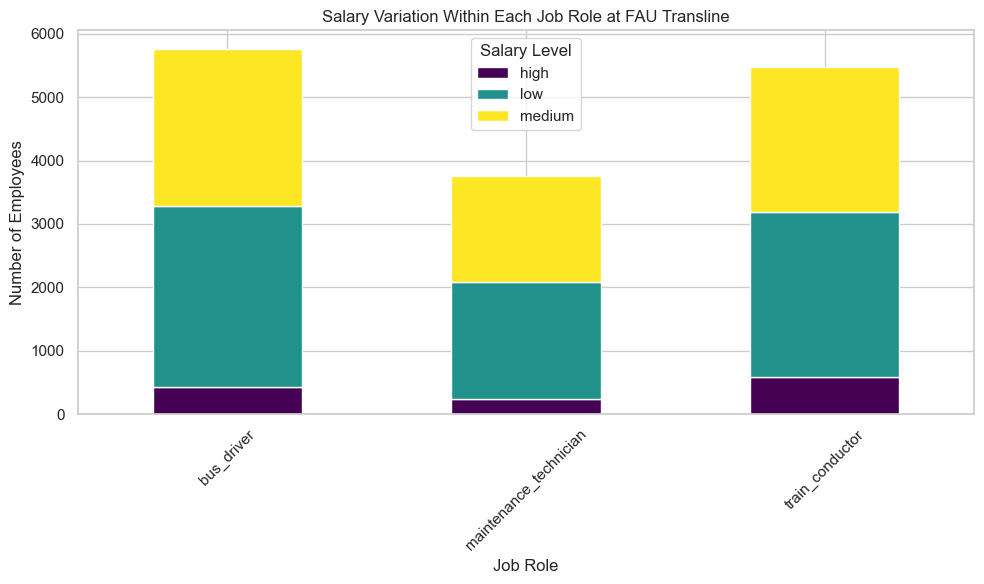

In [69]:
# Create a pivot table to count salary levels per job_role
salary_counts = df.pivot_table(index='job_role', columns='salary', 
                               aggfunc='size', fill_value=0)

# Plot stacked bar chart
salary_counts.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')

plt.title('Salary Variation Within Each Job Role at FAU Transline')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.legend(title='Salary Level')
plt.tight_layout()
plt.show()

#### 2. Average job satisfaction level of employees who left

In [70]:
employees_who_resigned = df[df['left'] == 1]
avg_job_satisfaction_level = employees_who_resigned['job_satisfaction_rate'].mean()
print(f"Average job satisfaction of employees who left: {avg_job_satisfaction_level:.2f}")

Average job satisfaction of employees who left: 0.44


#### 3. Average duration employees who left stayed with the company

In [71]:
avg_duration_time_spent = employees_who_resigned['time_spend_company'].mean()
print(f"Average duration (years) of stay for employees who resigned: {avg_duration_time_spent:.2f} years")

Average duration (years) of stay for employees who resigned: 3.88 years


### Data Preprocessing
Data preprocessing is essential for answering Question 4 and generating the correlation matrix. This is because correlation matrices require numerical data to properly calculate relationships between variables. Categorical features, such as 'job_role' and 'salary', must be converted into a numerical format before a meaningful correlation can be computed.

In [72]:
# Initialize LabelEncoders
job_role_encoder = LabelEncoder()
salary_encoder = LabelEncoder()

# Fit and transform the 'job_role' column in place
df['job_role'] = job_role_encoder.fit_transform(df['job_role'])

# Fit and transform the 'salary' column in place
df['salary'] = salary_encoder.fit_transform(df['salary'])

#### 4. Correlation matrix to determine 'left' correlation with other attributes

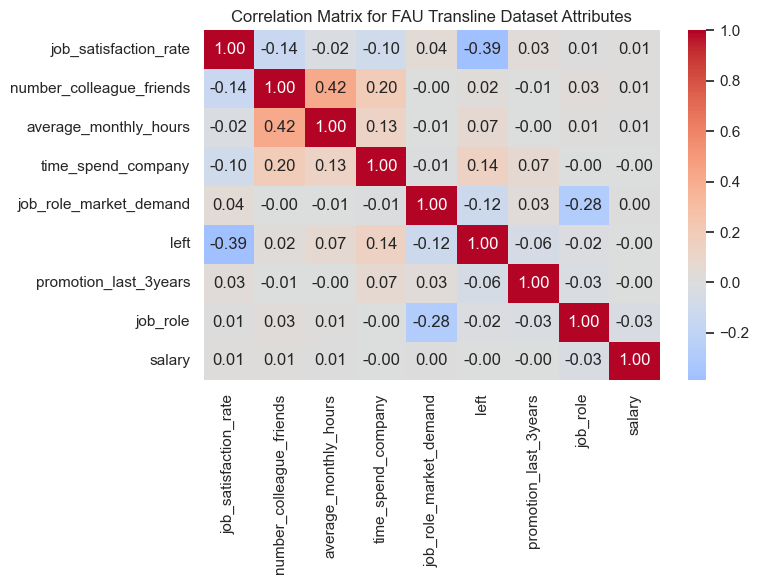

In [73]:
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix for FAU Transline Dataset Attributes')
plt.tight_layout()
plt.show()

In [74]:
# Get correlation of all features with WORK_LIFE_BALANCE_SCORE
left_correlation = correlation_matrix["left"].drop("left").sort_values(ascending=False)

# Round to 2 decimals
left_correlation_rounded = left_correlation.round(2)

# Display the sorted correlations
left_correlation_rounded

time_spend_company          0.14
average_monthly_hours       0.07
number_colleague_friends    0.02
salary                     -0.00
job_role                   -0.02
promotion_last_3years      -0.06
job_role_market_demand     -0.12
job_satisfaction_rate      -0.39
Name: left, dtype: float64

# 2.4 Employee Turnover Prediction

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [76]:
X = df.drop(columns=['left'])
y = data['left']

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0, stratify=y)

# Model selection: Random Forest Classifier
# Reason: Random Forest is robust, handles nonlinear relationships well, less prone to overfitting, and works well for classification tasks with mixed data types.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance on Test Set:")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Performance on Test Set:
Accuracy:  0.99
Precision: 0.99
Recall:    0.97
F1 Score:  0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3429
           1       0.99      0.97      0.98      1071

    accuracy                           0.99      4500
   macro avg       0.99      0.98      0.99      4500
weighted avg       0.99      0.99      0.99      4500



#### Confusion matrix visualization

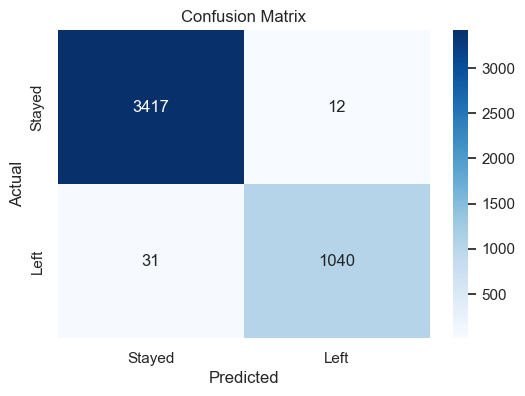

In [77]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

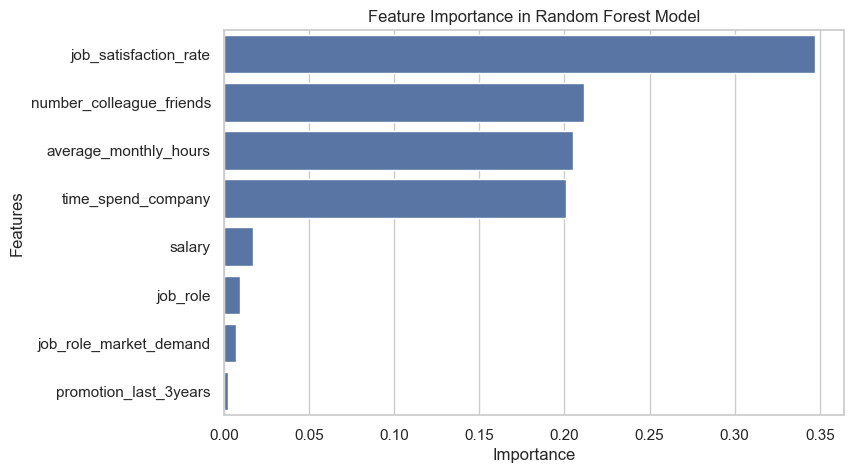



Feature Importances (from highest to lowest):

job_satisfaction_rate: 0.3470
number_colleague_friends: 0.2117
average_monthly_hours: 0.2050
time_spend_company: 0.2008
salary: 0.0170
job_role: 0.0091
job_role_market_demand: 0.0073
promotion_last_3years: 0.0021


In [78]:
# Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


print("\n\nFeature Importances (from highest to lowest):\n")
for i in indices:
    print(f"{X.columns[i]}: {importances[i]:.4f}")